## EDA

In [81]:
#Importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from sklearn import metrics

In [4]:
#importing data from google drive
dataset_calorie = pd.read_csv("calories.csv") 
#this data contains user_id and calories :two columns
dataset_exercise = pd.read_csv("exercise.csv")
#this contains 8 other activity parameters on which calories burnt may depend

In [5]:
dataset_calorie.head()

,User_ID,Calories
0,14733363,231.0
1,14861698,66.0
2,11179863,26.0
3,16180408,71.0
4,17771927,35.0


In [6]:
dataset_exercise.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8


In [ ]:
# To check for null values in the data and delete(drop) them if any
null_counts1 = dataset_calorie.isnull().sum() #check for 1st  dataset
print("Null Values in the Dataset:")
print(null_counts1)
null_counts2 = dataset_exercise.isnull().sum() #check for 2nd datset
print(null_counts2)

Null Values in the Dataset:
User_ID     0
Calories    0
dtype: int64
User_ID       0
Gender        0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
dtype: int64


The merged dataset was checked for missing values. No missing values were found, so no imputation or row removal was required.

In [8]:
#to check for any duplicate values in the data
print(dataset_calorie.duplicated().any())
print(dataset_exercise.duplicated().any())

False
False


In [ ]:
#combining both the dataset into one
dataset = pd.merge(
    dataset_exercise,
    dataset_calorie,
    on='User_ID',
    how='inner'
)

The exercise dataset contains demographic and activity-related features, while the calories dataset contains the target variable, Calories.
Both datasets contain User_ID, which is used as the common key to combine the datasets.

In [42]:
dataset.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


In [43]:
dataset.describe()

,User_ID,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,1.497736e+07,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453,89.539533
std,2.872851e+06,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230,62.456978
min,1.000116e+07,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,1.247419e+07,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,35.000000
50%,1.499728e+07,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000,79.000000
75%,1.744928e+07,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000,138.000000
max,1.999965e+07,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


In [ ]:
# To know the total no. of rows and columns
dataset.shape

(15000, 9)

In [45]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      15000 non-null  str    
 2   Age         15000 non-null  int64  
 3   Height      15000 non-null  float64
 4   Weight      15000 non-null  float64
 5   Duration    15000 non-null  float64
 6   Heart_Rate  15000 non-null  float64
 7   Body_Temp   15000 non-null  float64
 8   Calories    15000 non-null  float64
dtypes: float64(6), int64(2), str(1)
memory usage: 1.0 MB


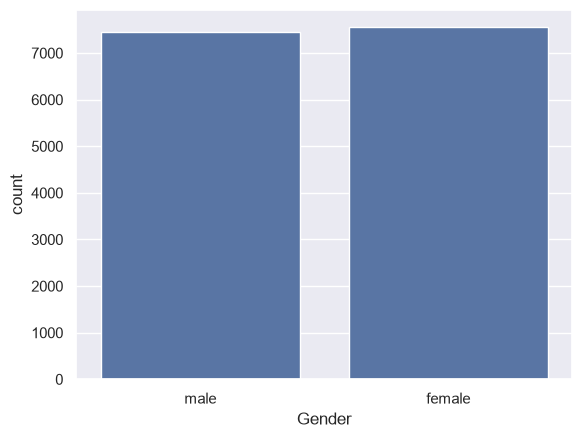

In [54]:
sns.set_theme()
sns.countplot(x='Gender',data=dataset)
plt.show()

In [47]:
dataset.Gender.value_counts()

Gender
female    7553
male      7447
Name: count, dtype: int64

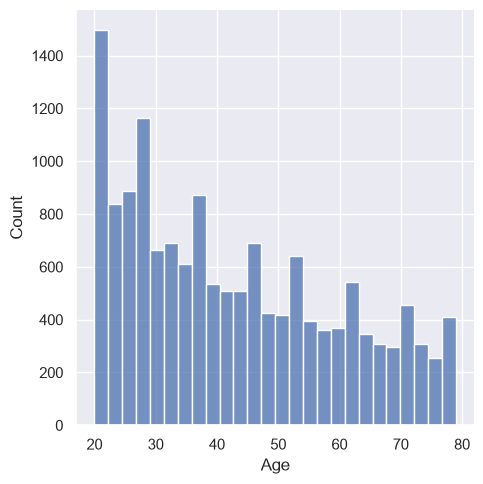

In [48]:
sns.displot(dataset['Age'])
plt.show()

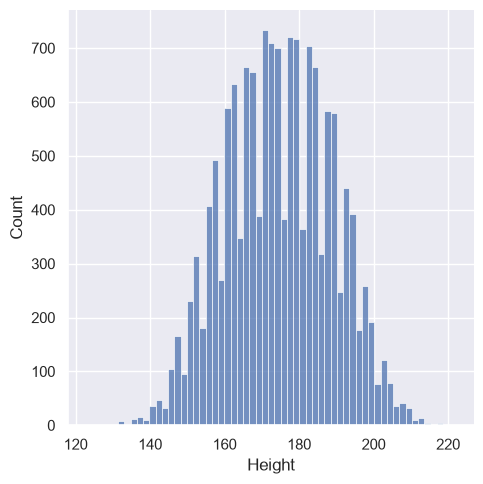

In [49]:
sns.displot(dataset['Height'])

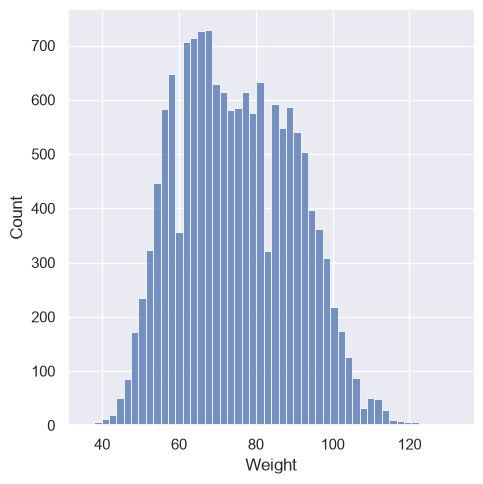

In [50]:
sns.displot(dataset['Weight'])

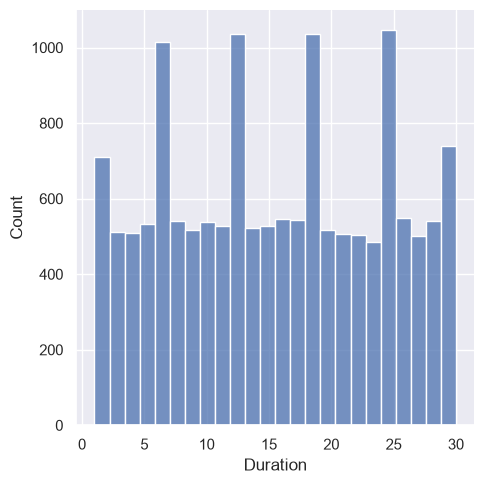

In [51]:
sns.displot(dataset['Duration'])

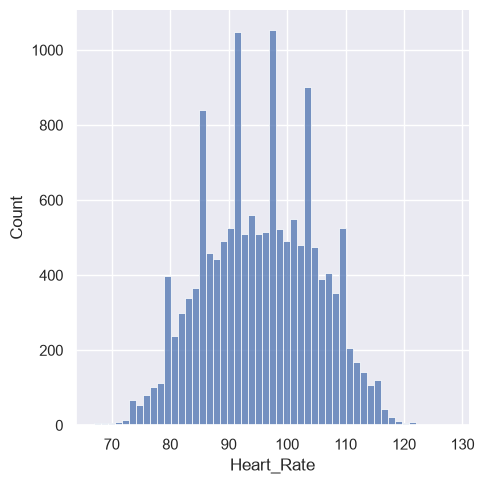

In [52]:
sns.displot(dataset['Heart_Rate'])

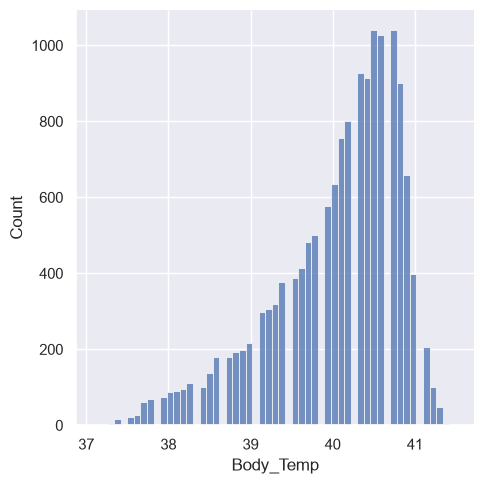

In [53]:
sns.displot(dataset['Body_Temp'])

## Data Preprocessing

The Gender column contains two categorical values, male and female.
Since the variable is binary, it is encoded numerically as:

- Male → 0
- Female → 1

In [63]:
dataset['Gender'] = dataset['Gender'].map({
    'male': 0,
    'female': 1
})

### Scaling 
XGBoost uses decision trees, and tree-based models don't depend on the numerical magnitude of features

### Outliers 
The variables in our table are physiological/activity variables, so extreme-looking observations aren't automatically errors.

In [66]:
# To find positive or negative correlation
correlation = dataset.corr()
correlation

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
User_ID,1.000000,0.000687,-0.001827,-0.013520,-0.011603,-0.002751,-0.000457,0.000923,-0.001661
Gender,0.000687,1.000000,-0.003222,-0.710534,-0.783186,-0.003440,-0.011555,-0.007264,-0.022357
Age,-0.001827,-0.003222,1.000000,0.009554,0.090094,0.013247,0.010482,0.013175,0.154395
Height,-0.013520,-0.710534,0.009554,1.000000,0.958451,-0.004625,0.000528,0.001200,0.017537
Weight,-0.011603,-0.783186,0.090094,0.958451,1.000000,-0.001884,0.004311,0.004095,0.035481
Duration,-0.002751,-0.003440,0.013247,-0.004625,-0.001884,1.000000,0.852869,0.903167,0.955421
Heart_Rate,-0.000457,-0.011555,0.010482,0.000528,0.004311,0.852869,1.000000,0.771529,0.897882
Body_Temp,0.000923,-0.007264,0.013175,0.001200,0.004095,0.903167,0.771529,1.000000,0.824558
Calories,-0.001661,-0.022357,0.154395,0.017537,0.035481,0.955421,0.897882,0.824558,1.000000


<Axes: >

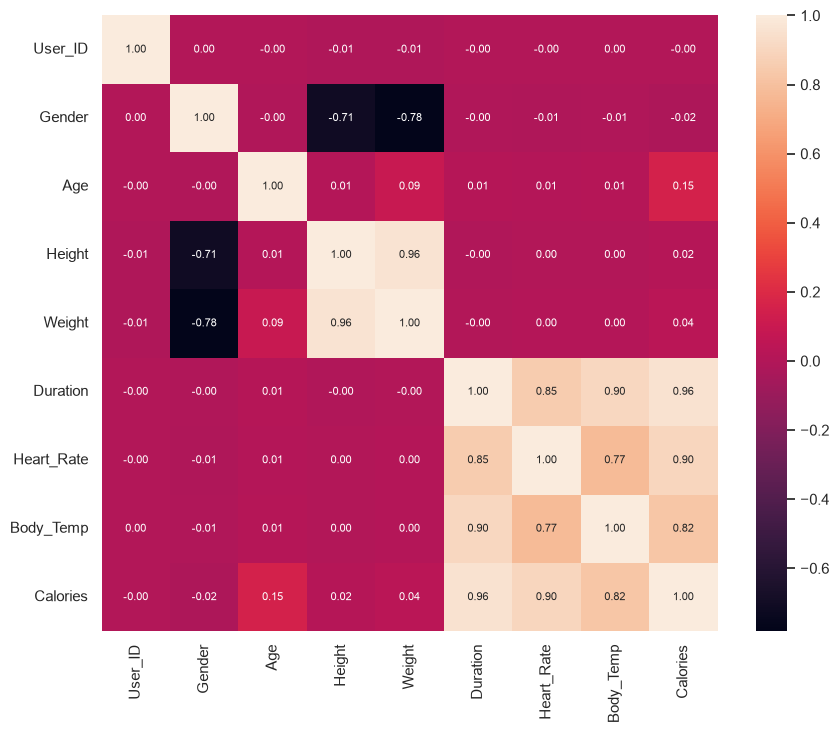

In [67]:
#plotting a heat map to understand and visualise the correlation with different parameters
plt.figure(figsize =(10,8))
sns.heatmap(correlation,annot =True,cbar=True, fmt ='0.2f',square=True, annot_kws={'size':8})

In [68]:
# To train the model we'll be separating the features and target as x and y
X=dataset.drop(['User_ID','Calories'],axis=1) #in X by dropping user_ID and Calories column
Y=dataset['Calories'] #where y includes only calorie column

In [69]:
print(X)

       Gender  Age  Height  Weight  Duration  Heart_Rate  Body_Temp
0           0   68   190.0    94.0      29.0       105.0       40.8
1           1   20   166.0    60.0      14.0        94.0       40.3
2           0   69   179.0    79.0       5.0        88.0       38.7
3           1   34   179.0    71.0      13.0       100.0       40.5
4           1   27   154.0    58.0      10.0        81.0       39.8
...       ...  ...     ...     ...       ...         ...        ...
14995       1   20   193.0    86.0      11.0        92.0       40.4
14996       1   27   165.0    65.0       6.0        85.0       39.2
14997       1   43   159.0    58.0      16.0        90.0       40.1
14998       0   78   193.0    97.0       2.0        84.0       38.3
14999       0   63   173.0    79.0      18.0        92.0       40.5

[15000 rows x 7 columns]


In [70]:
print(Y)

0        231.0
1         66.0
2         26.0
3         71.0
4         35.0
         ...  
14995     45.0
14996     23.0
14997     75.0
14998     11.0
14999     98.0
Name: Calories, Length: 15000, dtype: float64


## Model training & Prediction

In [71]:
# Splitting the data into training data and test data
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [72]:
print(X.shape,X_train.shape,X_test.shape)

(15000, 7) (12000, 7) (3000, 7)


In [96]:
# Loading the model
model = XGBRegressor(
    objective='reg:squarederror',
    random_state=42
)

In [97]:
# Cross validation to evaluate the model's performance
cv_scores = cross_val_score(
    model,
    X_train,
    Y_train,
    cv=5,
    scoring='neg_mean_absolute_error'
)

print("CV MAE scores:", -cv_scores)
print("Mean CV MAE:", -cv_scores.mean())

CV MAE scores: [1.51472365 1.5037979  1.57461596 1.60600612 1.63417767]
Mean CV MAE: 1.5666642612200232


In [98]:
# Hyperparameter tuning using RandomizedSearchCV
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

In [99]:
random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=20,
    scoring='neg_mean_absolute_error',
    cv=5,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, Y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], 'n_estimators': [100, 200, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSea

In [100]:
print("Best parameters:")
print(random_search.best_params_)

print("\nBest CV MAE:")
print(-random_search.best_score_)

Best parameters:
{'subsample': 0.9, 'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.8}

Best CV MAE:
1.0120100104731198


In [101]:
best_model = random_search.best_estimator_

In [ ]:
# Training the model
best_model.fit(X_train,Y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [89]:
Y_pred = best_model.predict(X_test)

mae = mean_absolute_error(Y_test, Y_pred)
rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))
r2 = r2_score(Y_test, Y_pred)

print("Test MAE:", mae)
print("Test RMSE:", rmse)
print("Test R²:", r2)

Test MAE: 0.9381404380997022
Test RMSE: 1.3014970963776813
Test R²: 0.9995802819096593


In [102]:
# Original/default XGBoost model
model.fit(X_train, Y_train)

baseline_pred = model.predict(X_test)

baseline_mae = mean_absolute_error(Y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(Y_test, baseline_pred))
baseline_r2 = r2_score(Y_test, baseline_pred)

print("Baseline Test MAE:", baseline_mae)
print("Baseline Test RMSE:", baseline_rmse)
print("Baseline Test R²:", baseline_r2)

Baseline Test MAE: 1.4981198125282924
Baseline Test RMSE: 2.1375116634132594
Baseline Test R²: 0.9988678909361673


In [108]:
best_model.score(X_train,Y_train)

0.999810660465647

In [109]:
best_model.score(X_test,Y_test)

0.9995802819096593

In [110]:
model.score(X_train,Y_train)

0.9995777219604748

In [111]:
model.score(X_test,Y_test)

0.9988678909361673

In [112]:
#seeing prediction on test data
test_dataset_prediction = best_model.predict(X_test)
test_dataset_prediction

array([174.40717, 190.22954,  52.59305, ..., 120.2278 ,  20.33151,
       212.90503], shape=(3000,), dtype=float32)

## Creating Pickle File

In [113]:
import joblib

joblib.dump(best_model, "calorie_model.pkl")

['calorie_model.pkl']

## Conclusion

In this project we developed a ML model to predict calories burned during exercise using demographic and exercise-related features such as age, gender, height, weight, duration, heart rate, and body temperature.

After preprocessing the data and performing exploratory data analysis, an **XGBoost Regressor** was selected for the prediction task. A baseline model was first trained using the default parameters. The model was then improved using **5-fold cross-validation and randomized hyperparameter tuning**, allowing parameters such as the number of estimators, tree depth, learning rate, subsampling, and feature sampling to be optimized.

The tuned model performed better than the baseline model on the held-out test set:

| Metric | Baseline XGBoost | Tuned XGBoost |
|:---|---:|---:|
| MAE | 1.498 | **0.938** |
| RMSE | 2.137 | **1.302** |
| R² | 0.99887 | **0.99958** |

The tuned model reduced the **MAE by approximately 37%** and the **RMSE by approximately 39%**, while also increasing the R² score. This indicates that hyperparameter tuning improved the model's predictive performance on the test data.